# Airbnb Price Prediction and Market Analysis

**Objective:** To analyze Airbnb listing data, identify key factors that influence pricing, segment the market using clustering, and build a predictive model for listing prices — with actionable business insights grounded in demand-supply theory.

**Methodology:**
1. Data Acquisition & Loading
2. Data Cleaning & Type Conversion
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. K-Means Clustering for Market Segmentation
6. Linear Regression for Price Prediction
7. Business & Economic Interpretation

**Tools & Libraries:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, KaggleHub

## 1. Data Acquisition & Loading

We download the Airbnb dataset from Kaggle using the `kagglehub` library and load it into a Pandas DataFrame. The dataset uses a semicolon delimiter, and rows with parsing errors are skipped to ensure a clean load.

In [ ]:
# Install kagglehub if not already present
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Download the Airbnb dataset from Kaggle
path = kagglehub.dataset_download("joebeachcapital/airbnb")
print("Downloaded to:", path)

# Identify the CSV file in the downloaded folder
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    source_path = os.path.join(path, csv_files[0])
    destination_path = "/content/airbnb_data.csv"
    shutil.copy(source_path, destination_path)
    print(f"Dataset copied to: {destination_path}")

    # Load into DataFrame (semicolon-separated, skip malformed rows)
    df = pd.read_csv(destination_path, sep=';', quotechar='"', on_bad_lines='skip', engine='python')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    display(df.head())
else:
    print("No CSV file found in the download.")

100%|██████████| 1.01G/1.01G [00:08<00:00, 132MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/joebeachcapital/airbnb/versions/1
Files in folder: ['airbnb-listings.geojson', 'airbnb-listings.csv']
File moved to: /content/airbnb_data.csv
Dataset Loaded Successfully!


,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,4008728,https://www.airbnb.com/rooms/4008728,20170402075052,2017-04-02,"Luxurious 3 bedroom, centrum, 180m2",‪This luxurious apartment is situated in the c...,In the heart of hip & lively Amsterdam Centrum...,‪This luxurious apartment is situated in the c...,none,There is a wide variety of cafes and restauran...,...,10.0,10.0,9.0,NaN,Amsterdam,strict,1.0,1.52,"52.36523660409065, 4.878249575101092","Host Has Profile Pic,Host Identity Verified,Is..."
1,7778612,https://www.airbnb.com/rooms/7778612,20170402075052,2017-04-02,Luxury apartment in city centre,"Beautiful, large (105m2, 2 floors) and quiet a...",1 living room 1 dining room 2 bedrooms 1 bathr...,"Beautiful, large (105m2, 2 floors) and quiet a...",none,Within a few minutes walking you'll be in the ...,...,10.0,10.0,9.0,NaN,Amsterdam,strict,1.0,0.81,"52.367309030897516, 4.8738407410699915","Host Is Superhost,Host Has Profile Pic,Host Id..."
2,8264596,https://www.airbnb.com/rooms/8264596,20170402075052,2017-04-02,Cosy apartment across Vondelpark,This central located apartment will make you f...,NaN,This central located apartment will make you f...,none,NaN,...,10.0,10.0,10.0,NaN,Amsterdam,flexible,1.0,0.05,"52.361943953804776, 4.866686522141489","Host Has Profile Pic,Host Identity Verified,Is..."
3,2180729,https://www.airbnb.com/rooms/2180729,20170402075052,2017-04-02,Spacious City Apartment Oud-West,Living like an Amsterdam resident in this ligh...,There are 2 bedrooms each with a double bed. I...,Living like an Amsterdam resident in this ligh...,none,The 85 m2 apartment is located on a quiet stre...,...,9.0,9.0,9.0,NaN,Amsterdam,flexible,1.0,0.62,"52.37014616115532, 4.866281767968382","Host Has Profile Pic,Host Identity Verified,Is..."
4,14463171,https://www.airbnb.com/rooms/14463171,20170402075052,2017-04-02,Cosy Studio Apartment Center Amsterdam,Studio Apartment Centre Amsterdam Perfect stud...,NaN,Studio Apartment Centre Amsterdam Perfect stud...,none,NaN,...,8.0,9.0,9.0,NaN,Amsterdam,moderate,1.0,2.04,"52.368817829014425, 4.871249476925455",Host Has Profile Pic


## 2. Data Cleaning & Type Conversion

We perform the following cleaning steps:
- Remove duplicate records based on listing ID
- Convert currency columns (e.g., `$1,200.00`) to numeric floats
- Convert percentage columns to decimal proportions
- Parse date strings into datetime objects
- Inspect remaining missing values

In [ ]:
# Remove duplicate rows based on listing ID
print(f"Rows before deduplication: {df.shape[0]}")
df.drop_duplicates(subset=['ID'], keep='first', inplace=True)
print(f"Rows after deduplication:  {df.shape[0]}")

Number of rows before removing duplicates: 494954
Number of rows after removing duplicates: 494952


In [ ]:
# Clean currency columns — remove '$' and ',' symbols, convert to float
currency_cols = ['Price', 'Weekly Price', 'Monthly Price', 'Security Deposit', 'Cleaning Fee', 'Extra People']

for col in currency_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

print("Currency columns cleaned and converted to float.")
display(df[currency_cols].head())

Currency columns cleaned and converted to float.


,Price,Weekly Price,Monthly Price,Security Deposit,Cleaning Fee,Extra People
0,600.0,NaN,6000.0,500.0,50.0,50.0
1,175.0,NaN,4000.0,400.0,40.0,30.0
2,125.0,600.0,NaN,NaN,NaN,0.0
3,130.0,NaN,NaN,100.0,45.0,25.0
4,80.0,NaN,NaN,100.0,25.0,0.0


In [ ]:
# Clean 'Host Response Rate' — remove '%' and convert to proportion (0–1)
if 'Host Response Rate' in df.columns:
    if df['Host Response Rate'].dtype == 'object':
        df['Host Response Rate'] = df['Host Response Rate'].astype(str).str.replace('%', '', regex=False)
        df['Host Response Rate'] = pd.to_numeric(df['Host Response Rate'], errors='coerce') / 100
    else:
        df['Host Response Rate'] = pd.to_numeric(df['Host Response Rate'], errors='coerce')
        if df['Host Response Rate'].max() > 1:
            df['Host Response Rate'] = df['Host Response Rate'] / 100

    print("Host Response Rate cleaned and converted to proportion.")
    display(df[['Host Response Rate']].head())

Host Response Rate column cleaned and converted to float (proportion).


,Host Response Rate
0,0.5
1,1.0
2,NaN
3,1.0
4,1.0


In [ ]:
# Convert date columns to datetime objects
date_cols = ['Host Since', 'Calendar Last Scraped', 'First Review', 'Last Review']
processed_date_cols = []

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        processed_date_cols.append(col)
    else:
        print(f"  Column '{col}' not found — skipped.")

print(f"Date columns converted: {processed_date_cols}")
if processed_date_cols:
    display(df[processed_date_cols].dtypes)

Column 'Calendar Last Scraped' not found in DataFrame and skipped.
Date columns converted to datetime objects.


,Host Since,First Review,Last Review
0,2014-09-01,2015-08-02,2016-11-27
1,2014-02-05,2015-09-28,2017-01-19
2,2014-11-12,2015-09-22,2015-09-22
3,2013-10-05,2014-05-12,2016-07-19
4,2016-08-10,2016-08-11,2017-03-06


,0
Host Since,datetime64[ns]
First Review,datetime64[ns]
Last Review,datetime64[ns]


In [ ]:
# Inspect missing values across the dataset
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
display(missing)

Missing values per column:


,0
Has Availability,485645
Square Feet,482743
License,480356
Host Acceptance Rate,452696
Monthly Price,398862
...,...
Room Type,1
Neighbourhood Cleansed,1
Street,1
Calendar Updated,1


## 3. Feature Engineering

In this section, we create new derived features to enrich the dataset and improve the predictive power of our model:
- **Price per Bedroom** — Normalizes price relative to the number of bedrooms.
- **Review Month (Seasonality)** — Captures the month of the last review to account for seasonal trends.
- **Booking Density** — Estimates the average number of reviews per month as a proxy for booking frequency.

In [ ]:
# 3.1 Price per Bedroom
if 'Price' in df.columns and 'Bedrooms' in df.columns:
    df['Bedrooms_cleaned'] = df['Bedrooms'].replace(0, 1).fillna(1)
    df['Price per Bedroom'] = df['Price'] / df['Bedrooms_cleaned']
    df['Price per Bedroom'] = df['Price per Bedroom'].replace([np.inf, -np.inf], np.nan)
    print("'Price per Bedroom' feature created.")
    display(df[['Price', 'Bedrooms', 'Price per Bedroom']].head())

# 3.2 Review Month (Seasonality)
if 'Last Review' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Last Review']):
    df['Review Month'] = df['Last Review'].dt.month
    print("'Review Month' feature created.")
    display(df[['Last Review', 'Review Month']].head())

'Price per Bedroom' feature created.


/tmp/ipython-input-149/1976746848.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price per Bedroom'].replace([np.inf, -np.inf], np.nan, inplace=True)


,Price,Bedrooms,Bedrooms_cleaned,Price per Bedroom
0,600.0,3.0,3.0,200.0
1,175.0,2.0,2.0,87.5
2,125.0,2.0,2.0,62.5
3,130.0,2.0,2.0,65.0
4,80.0,0.0,1.0,80.0


,0
Price per Bedroom,float64


In [ ]:
# 3.3 Booking Density (reviews per month as a proxy for booking frequency)
if all(col in df.columns for col in ['Number of Reviews', 'First Review', 'Last Review']):
    df['First Review'] = pd.to_datetime(df['First Review'], errors='coerce')
    df['Last Review'] = pd.to_datetime(df['Last Review'], errors='coerce')

    # Calculate the number of days a listing has been active
    df['days_active'] = (df['Last Review'] - df['First Review']).dt.days
    df['days_active'] = df['days_active'].replace(0, 1).fillna(1)

    # Booking Density = reviews per month (avg 30.44 days/month)
    df['Booking Density'] = (df['Number of Reviews'] / df['days_active']) * 30.44
    df['Booking Density'] = df['Booking Density'].replace([np.inf, -np.inf], np.nan)

    print("'Booking Density' feature created.")
    display(df[['Number of Reviews', 'First Review', 'Last Review', 'days_active', 'Booking Density']].head())

'Booking Density' feature created.


,Number of Reviews,First Review,Last Review,days_active,Booking Density
0,31.0,2015-08-02,2016-11-27,483.0,1.953706
1,15.0,2015-09-28,2017-01-19,479.0,0.953236
2,1.0,2015-09-22,2015-09-22,1.0,30.440000
3,22.0,2014-05-12,2016-07-19,799.0,0.838148
4,16.0,2016-08-11,2017-03-06,207.0,2.352850


,0
Booking Density,float64


## 4. Exploratory Data Analysis — Price Distribution

We analyze the global distribution of listing prices using histograms and box plots, and identify the top-performing regions based on average price.

Libraries imported successfully.


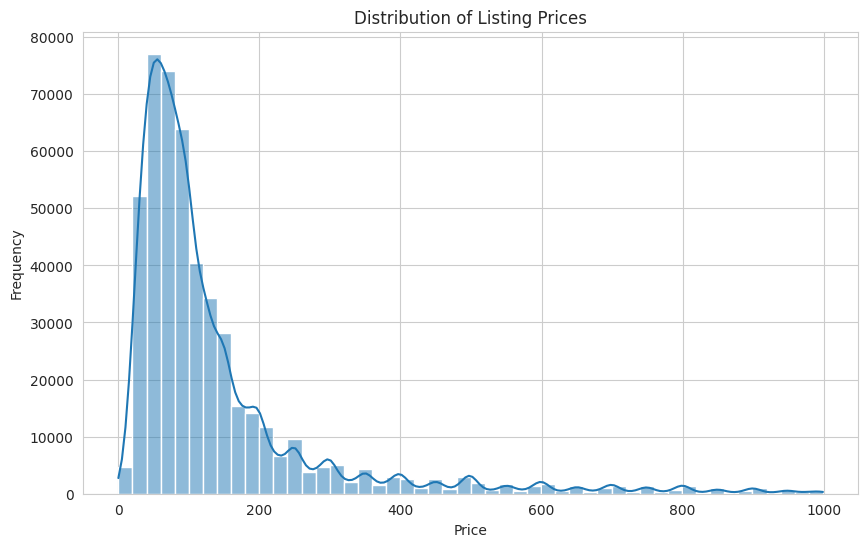

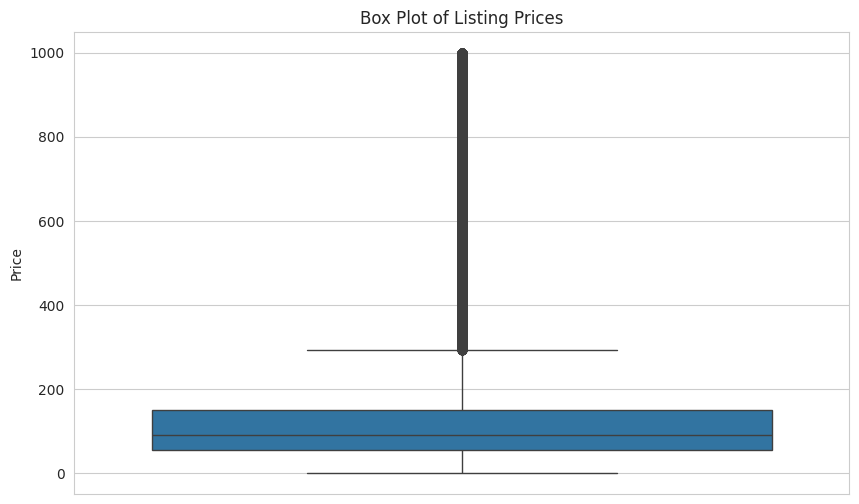

Price distribution visualizations generated.


In [ ]:
sns.set_style("whitegrid")

# 4.1 Histogram of listing prices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Listing Prices')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# 4.2 Box plot of listing prices
sns.boxplot(y=df['Price'], ax=axes[1])
axes[1].set_title('Box Plot of Listing Prices')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

Top 10 Regions by Average Listing Price:


,Price
Neighbourhood Cleansed,
Indre By,692.633560
Hiller Highlands,650.000000
Southern,643.261905
Vesterbro-Kongens Enghave,635.525417
Frederiksberg,620.503671
Amager Vest,615.666426
Central & Western,600.433695
Islands,595.632035
sterbro,584.927690


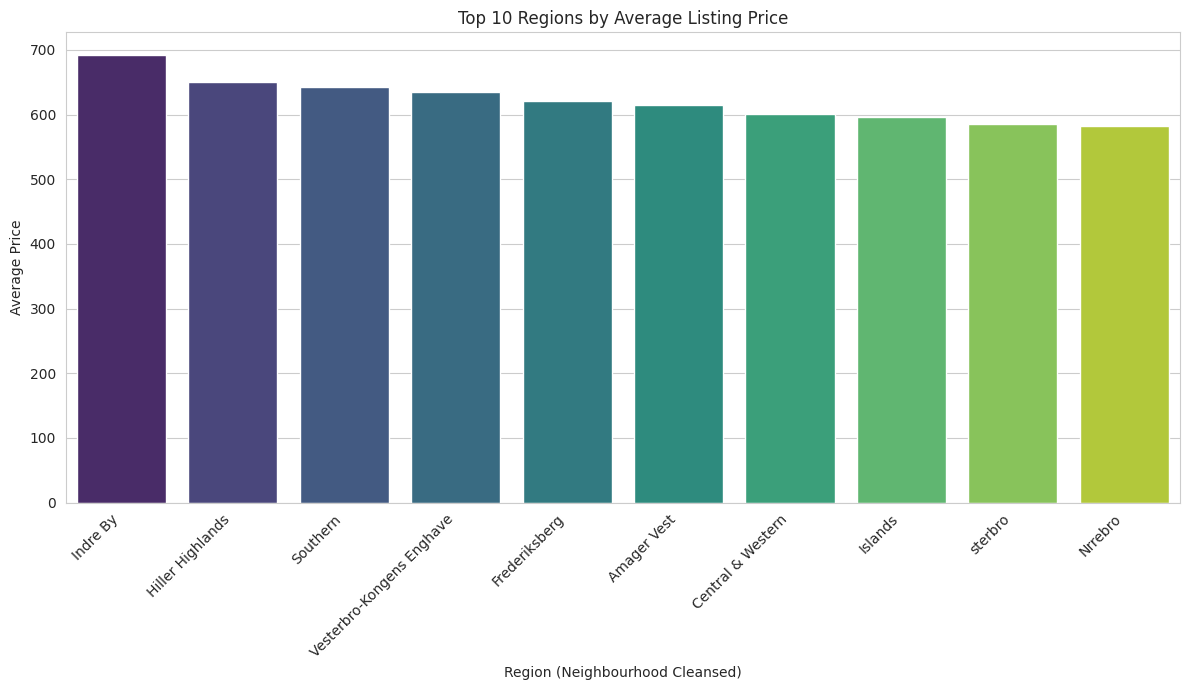

Top 10 regions by average price visualized.


In [ ]:
# 4.3 Top 10 regions by average listing price
avg_price_by_region = df.groupby('Neighbourhood Cleansed')['Price'].mean().sort_values(ascending=False)
top_10_regions = avg_price_by_region.head(10)

print("Top 10 Regions by Average Listing Price:")
display(top_10_regions)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_regions.index, y=top_10_regions.values,
            hue=top_10_regions.index, palette='viridis', legend=False)
plt.title('Top 10 Regions by Average Listing Price')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis — Price Correlations

We examine how price correlates with key variables such as room type, number of reviews, and availability using box plots and scatter plots.

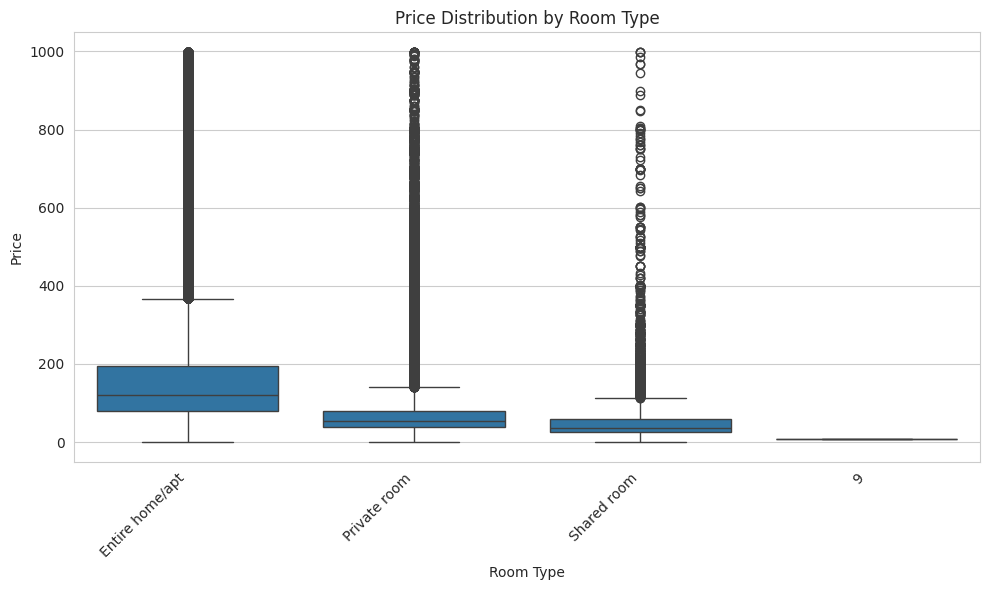

Box plot of Price by Room Type generated.


In [ ]:
# 5.1 Price distribution by Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Room Type', y='Price', data=df)
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

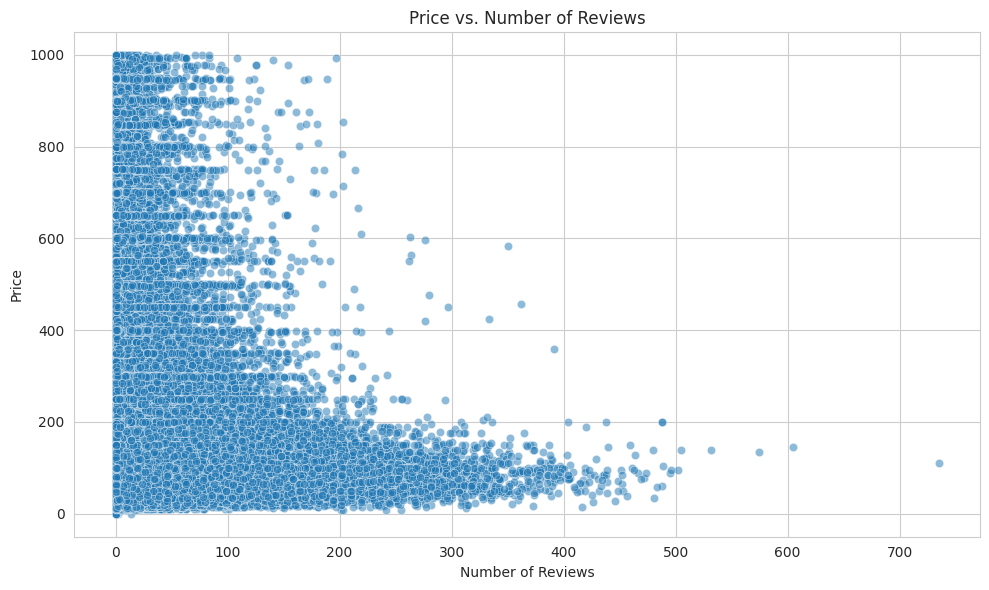

Scatter plot of Price by Number of Reviews generated.


In [ ]:
# 5.2 Price vs. Number of Reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number of Reviews', y='Price', data=df, alpha=0.5)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

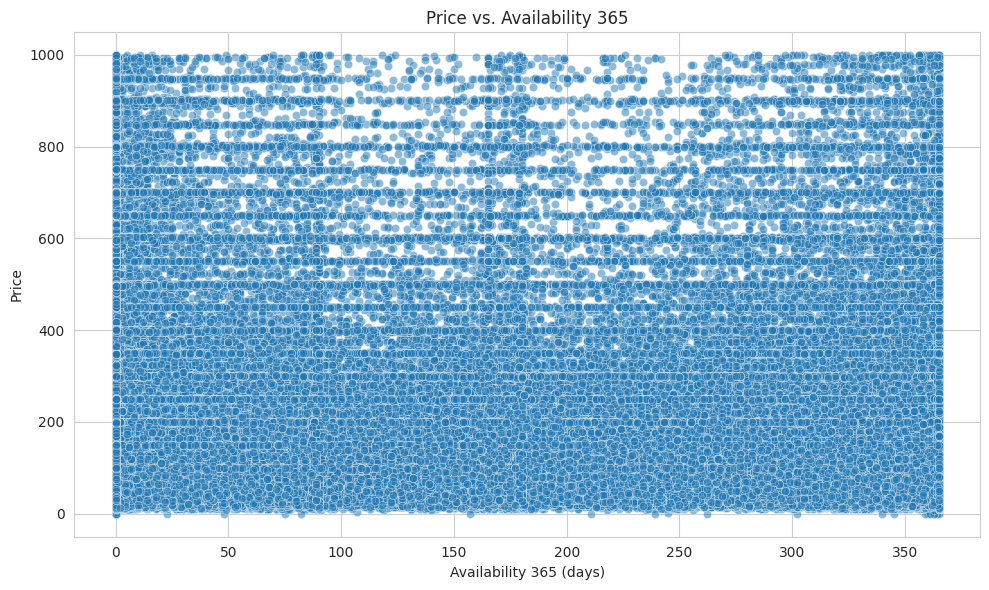

Scatter plot of Price by Availability 365 generated.


In [ ]:
# 5.3 Price vs. Availability (365 days)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Availability 365', y='Price', data=df, alpha=0.5)
plt.title('Price vs. Availability 365')
plt.xlabel('Availability (days/year)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

## 6. K-Means Clustering — Market Segmentation

We apply K-Means clustering to segment Airbnb listings into distinct market categories (e.g., Budget, Mid-range, Luxury) based on numerical features. The optimal number of clusters is determined using the Elbow method.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 6.1 Select numerical features for clustering
clustering_features = [
    'Price', 'Accommodates', 'Bathrooms', 'Bedrooms', 'Beds',
    'Review Scores Rating', 'Number of Reviews', 'Price per Bedroom', 'Booking Density'
]

df_clustering = df[clustering_features].copy()
print(f"Shape before dropping NaNs: {df_clustering.shape}")
df_clustering.dropna(inplace=True)
print(f"Shape after dropping NaNs:  {df_clustering.shape}")

# 6.2 Standardize features for distance-based clustering
scaler_kmeans = StandardScaler()
df_scaled = scaler_kmeans.fit_transform(df_clustering)

display(df_clustering.head())

Shape of df_clustering before dropping NaNs: (494952, 9)
Shape of df_clustering after dropping NaNs: (360764, 9)

First 5 rows of the clustering dataset:


,Price,Accommodates,Bathrooms,Bedrooms,Beds,Review Scores Rating,Number of Reviews,Price per Bedroom,Booking Density
0,600.0,6.0,1.0,3.0,3.0,89.0,31.0,200.0,1.953706
1,175.0,4.0,1.0,2.0,2.0,99.0,15.0,87.5,0.953236
2,125.0,4.0,1.0,2.0,2.0,100.0,1.0,62.5,30.440000
3,130.0,4.0,1.0,2.0,4.0,97.0,22.0,65.0,0.838148
4,80.0,2.0,1.0,0.0,1.0,78.0,16.0,80.0,2.352850



Data types of the clustering features:


,0
Price,float64
Accommodates,float64
Bathrooms,float64
Bedrooms,float64
Beds,float64
Review Scores Rating,float64
Number of Reviews,float64
Price per Bedroom,float64
Booking Density,float64


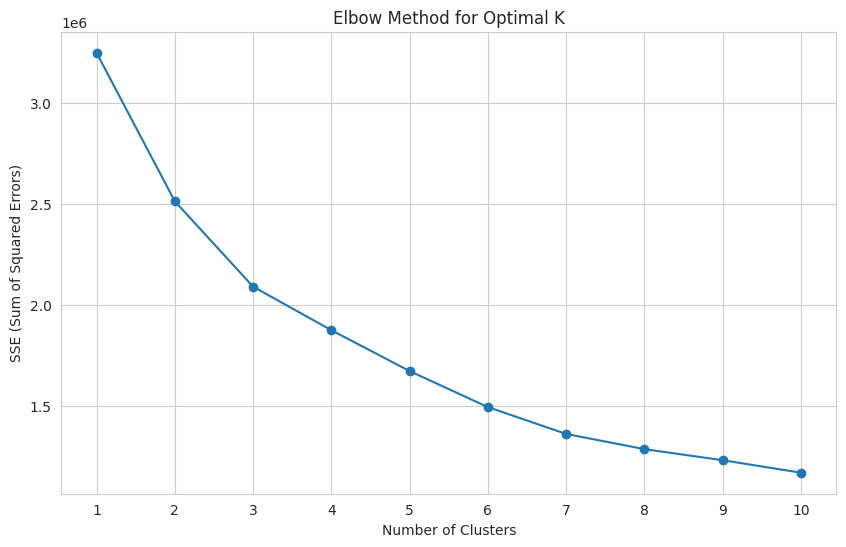

Elbow method plot generated to determine optimal number of clusters.


In [ ]:
# 6.3 Elbow Method — determine optimal number of clusters
sse = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

In [ ]:
# 6.4 Apply K-Means with K=3 (Budget, Mid-range, Luxury)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels back to the dataframe
df_clustering['Cluster'] = cluster_labels
df = df.merge(df_clustering[['Cluster']], left_index=True, right_index=True, how='left')

print(f"K-Means clustering applied with K={optimal_k}")
display(df[['Price', 'Accommodates', 'Cluster']].head())

K-Means clustering applied with 3 clusters.
Cluster labels added to DataFrame.


,Price,Accommodates,Cluster
0,600.0,6.0,0.0
1,175.0,4.0,2.0
2,125.0,4.0,2.0
3,130.0,4.0,2.0
4,80.0,2.0,2.0


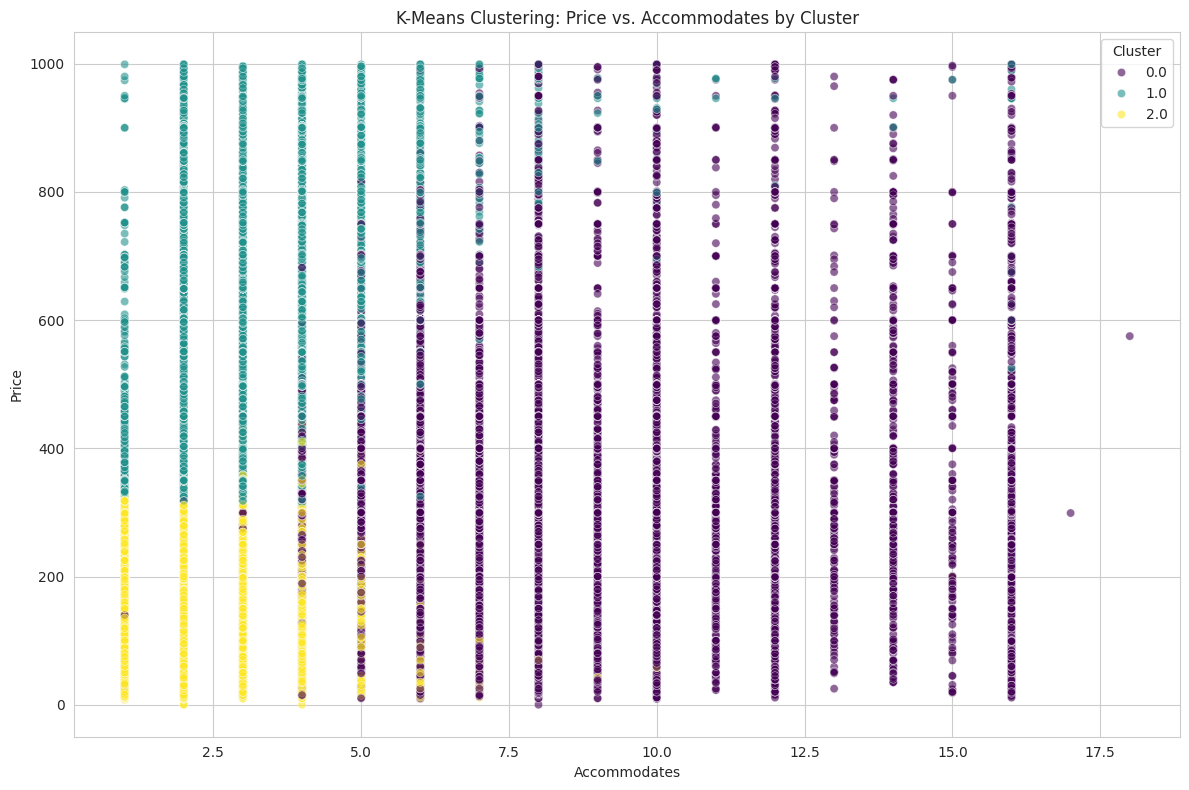

Cluster visualization (Price vs. Accommodates) generated.


In [ ]:
# 6.5 Visualize clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Accommodates', y='Price', hue='Cluster', data=df, palette='viridis', alpha=0.6)
plt.title('K-Means Clustering: Price vs. Accommodates')
plt.xlabel('Accommodates')
plt.ylabel('Price ($)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 6.6 Cluster characteristics — mean feature values per cluster
cluster_means = df_clustering.groupby('Cluster')[clustering_features].mean()
print("Mean feature values per cluster:")
display(cluster_means)


Analyzing cluster characteristics (mean of features for each cluster):


,Price,Accommodates,Bathrooms,Bedrooms,Beds,Review Scores Rating,Number of Reviews,Price per Bedroom,Booking Density
Cluster,,,,,,,,,
0,221.578778,6.495597,1.929065,2.728377,4.112191,92.882363,20.209151,83.549037,6.073224
1,613.830602,3.061583,1.066903,1.267551,1.682669,93.519080,13.757828,508.838876,6.333467
2,87.736124,2.620814,1.075893,1.038543,1.440718,92.864795,23.626883,79.268452,6.237863


Cluster characteristics analysis complete.


## 7. Regression Model — Data Preparation

We prepare the data for the Linear Regression model by selecting relevant features, encoding categorical variables, handling missing values, applying feature scaling, and splitting the dataset into training and testing sets.

In [ ]:
# 7.1 Define target variable and feature set
y = df['Price']

selected_features = [
    'Accommodates', 'Bathrooms', 'Bedrooms', 'Beds',
    'Review Scores Rating', 'Number of Reviews', 'Availability 365',
    'Price per Bedroom', 'Booking Density', 'Review Month',
    'Room Type', 'Neighbourhood Cleansed', 'Cluster'
]

existing_features = [f for f in selected_features if f in df.columns]
X = df[existing_features].copy()

print(f"Target: Price | Features selected: {len(existing_features)}")
display(X.head())

Target variable 'y' (Price) defined.


,Price
0,600.0
1,175.0
2,125.0
3,130.0
4,80.0


In [ ]:
# 7.2 One-hot encode categorical features
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f"One-hot encoding: {cat_cols}")
    X = pd.get_dummies(X, columns=cat_cols, dummy_na=False)

print(f"Feature matrix shape after encoding: {X.shape}")

Categorical columns to be one-hot encoded: ['Room Type', 'Neighbourhood Cleansed']
Categorical features one-hot encoded.


,Accommodates,Bathrooms,Bedrooms,Beds,Review Scores Rating,Number of Reviews,Availability 365,Price per Bedroom,Booking Density,Review Month,...,Neighbourhood Cleansed_ΠΕΤΡΑΛΩΝΑ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,Neighbourhood Cleansed_ΠΟΛΥΓΩΝΟ,Neighbourhood Cleansed_ΠΡΟΜΠΟΝΑ,Neighbourhood Cleansed_ΡΗΓΙΛΛΗΣ,Neighbourhood Cleansed_ΡΙΖΟΥΠΟΛΗ,Neighbourhood Cleansed_ΣΕΠΟΛΙΑ,Neighbourhood Cleansed_ΣΤΑΔΙΟ,Neighbourhood Cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
0,6.0,1.0,3.0,3.0,89.0,31.0,74.0,200.0,1.953706,11.0,...,False,False,False,False,False,False,False,False,False,False
1,4.0,1.0,2.0,2.0,99.0,15.0,259.0,87.5,0.953236,1.0,...,False,False,False,False,False,False,False,False,False,False
2,4.0,1.0,2.0,2.0,100.0,1.0,0.0,62.5,30.440000,9.0,...,False,False,False,False,False,False,False,False,False,False
3,4.0,1.0,2.0,4.0,97.0,22.0,0.0,65.0,0.838148,7.0,...,False,False,False,False,False,False,False,False,False,False
4,2.0,1.0,0.0,1.0,78.0,16.0,326.0,80.0,2.352850,3.0,...,False,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 494952 entries, 0 to 494953
Columns: 2394 entries, Accommodates to Neighbourhood Cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
dtypes: bool(2383), float64(11)
memory usage: 1.1 GB


None

In [ ]:
# 7.3 Handle missing values — drop rows with NaN in X or y
df_combined = pd.concat([X, y], axis=1)
df_combined.dropna(inplace=True)

X = df_combined.drop('Price', axis=1)
y = df_combined['Price']

print(f"After dropping NaNs — X: {X.shape}, y: {y.shape}")

Shape of X before dropping NaNs: (494952, 2394)
Shape of y before dropping NaNs: (494952,)
Shape of X after dropping NaNs: (360644, 2394)
Shape of y after dropping NaNs: (360644,)
Missing values handled in X and y.


,Accommodates,Bathrooms,Bedrooms,Beds,Review Scores Rating,Number of Reviews,Availability 365,Price per Bedroom,Booking Density,Review Month,...,Neighbourhood Cleansed_ΠΕΤΡΑΛΩΝΑ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,Neighbourhood Cleansed_ΠΟΛΥΓΩΝΟ,Neighbourhood Cleansed_ΠΡΟΜΠΟΝΑ,Neighbourhood Cleansed_ΡΗΓΙΛΛΗΣ,Neighbourhood Cleansed_ΡΙΖΟΥΠΟΛΗ,Neighbourhood Cleansed_ΣΕΠΟΛΙΑ,Neighbourhood Cleansed_ΣΤΑΔΙΟ,Neighbourhood Cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
0,6.0,1.0,3.0,3.0,89.0,31.0,74.0,200.0,1.953706,11.0,...,False,False,False,False,False,False,False,False,False,False
1,4.0,1.0,2.0,2.0,99.0,15.0,259.0,87.5,0.953236,1.0,...,False,False,False,False,False,False,False,False,False,False
2,4.0,1.0,2.0,2.0,100.0,1.0,0.0,62.5,30.440000,9.0,...,False,False,False,False,False,False,False,False,False,False
3,4.0,1.0,2.0,4.0,97.0,22.0,0.0,65.0,0.838148,7.0,...,False,False,False,False,False,False,False,False,False,False
4,2.0,1.0,0.0,1.0,78.0,16.0,326.0,80.0,2.352850,3.0,...,False,False,False,False,False,False,False,False,False,False


,Price
0,600.0
1,175.0
2,125.0
3,130.0
4,80.0


In [ ]:
# 7.4 Scale numerical features using StandardScaler
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
boolean_cols = X.select_dtypes(include=['bool']).columns

scaler_reg = StandardScaler()
X_scaled_num = pd.DataFrame(
    scaler_reg.fit_transform(X[numerical_cols]),
    columns=numerical_cols, index=X.index
)

# Combine scaled numerical + boolean (one-hot encoded) columns
X_scaled = pd.concat([X_scaled_num, X[boolean_cols]], axis=1)

print(f"Scaled feature matrix shape: {X_scaled.shape}")

Numerical features in X scaled successfully.


,Accommodates,Bathrooms,Bedrooms,Beds,Review Scores Rating,Number of Reviews,Availability 365,Price per Bedroom,Booking Density,Review Month,...,Neighbourhood Cleansed_ΠΕΤΡΑΛΩΝΑ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,Neighbourhood Cleansed_ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,Neighbourhood Cleansed_ΠΟΛΥΓΩΝΟ,Neighbourhood Cleansed_ΠΡΟΜΠΟΝΑ,Neighbourhood Cleansed_ΡΗΓΙΛΛΗΣ,Neighbourhood Cleansed_ΡΙΖΟΥΠΟΛΗ,Neighbourhood Cleansed_ΣΕΠΟΛΙΑ,Neighbourhood Cleansed_ΣΤΑΔΙΟ,Neighbourhood Cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
0,1.343297,-0.406635,1.903500,0.766083,-0.455890,0.234574,-0.725719,0.932102,-0.424579,1.846901,...,False,False,False,False,False,False,False,False,False,False
1,0.348812,-0.406635,0.759782,0.066437,0.713595,-0.212429,0.626911,-0.111107,-0.526005,-1.309700,...,False,False,False,False,False,False,False,False,False,False
2,0.348812,-0.406635,0.759782,0.066437,0.830543,-0.603557,-1.266771,-0.342931,2.463328,1.215581,...,False,False,False,False,False,False,False,False,False,False
3,0.348812,-0.406635,0.759782,1.465730,0.479698,-0.016865,-1.266771,-0.319749,-0.537673,0.584261,...,False,False,False,False,False,False,False,False,False,False
4,-0.645673,-0.406635,-1.527654,-0.633210,-1.742323,-0.184492,1.116783,-0.180654,-0.384114,-0.678380,...,False,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 360644 entries, 0 to 494951
Columns: 2394 entries, Accommodates to Neighbourhood Cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
dtypes: bool(2383), float64(11)
memory usage: 852.6 MB


None

In [ ]:
# 7.5 Train-test split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Data split into training and testing sets.
X_train shape: (288515, 2394)
X_test shape: (72129, 2394)
y_train shape: (288515,)
y_test shape: (72129,)


## 8. Linear Regression — Model Training & Evaluation

We train a Linear Regression model to predict listing prices and evaluate its performance using R-squared and Root Mean Squared Error (RMSE) on the held-out test set.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 8.1 Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")

# 8.2 Evaluate on the test set
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nRoot Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R²):                 {r2:.4f}")

Training Linear Regression model...


In [ ]:
# 8.3 Feature importance — top 20 coefficients by magnitude
coefficients = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': model.coef_
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("Top 20 most impactful features:")
display(coefficients.head(20)[['Feature', 'Coefficient']])

Model or X_scaled not found. Please ensure previous steps are executed.


## 9. Business & Economic Interpretation

### 9.1 Coefficient Analysis — Demand-Supply Perspective

Based on the Linear Regression model coefficients, we can infer the following relationships between features and price:

**Positive Coefficients (Higher Price):**
- **Accommodates, Bedrooms, Bathrooms, Beds:** Listings with greater capacity command higher prices — reflecting higher demand for spacious properties and higher supply-side investment.
- **Review Scores Rating:** Better-rated properties charge a premium, driven by trust and quality assurance from guests.
- **Entire home/apt (Room Type):** Entire homes offer privacy and self-sufficiency, leading to higher willingness to pay.
- **Prime Neighbourhoods:** Desirable locations (city centres, tourist areas) have high demand relative to supply, enabling premium pricing.

**Negative Coefficients (Lower Price):**
- **Availability 365:** Listings with year-round availability may indicate lower demand or a host strategy of competitive pricing to attract bookings.
- **Shared/Private Room Types:** These room types consistently command lower prices than entire homes.

**Key Insight:** The model captures classic demand-supply dynamics — scarcity (low availability + high demand) drives prices up, while abundance (high availability + low demand) pushes prices down.

### 9.2 Revenue Optimization Strategies for Hosts

1. **Dynamic Pricing:** Adjust prices based on seasonality, local events, and competitor analysis. Charge a premium during peak demand periods and offer competitive rates during off-peak seasons.
2. **Quality Investment:** Prioritize guest experience to improve review scores — cleanliness, accurate descriptions, responsive communication, and thoughtful amenities directly translate into higher willingness to pay.
3. **Strategic Availability Management:** Reduce availability during high-demand windows to create scarcity. Consider long-term stays at a slight discount during low-demand periods to maintain consistent occupancy.
4. **Market Segment Awareness:** Understand whether a listing falls into the Budget, Mid-range, or Luxury cluster. Align pricing, amenities, and marketing accordingly — a budget listing priced as luxury will receive poor reviews, while a luxury listing priced too low leaves revenue on the table.
5. **Location Leverage:** Hosts in high-demand neighbourhoods should capitalize on location with premium pricing. Hosts in less popular areas should differentiate through unique amenities, superior service, or competitive rates.

### 9.3 Risk Analysis — Overpricing vs. Underpricing

| Factor | Overpricing Risk | Underpricing Risk |
|--------|-----------------|-------------------|
| **Occupancy** | Significant drop in bookings | High occupancy but unfavourable effort-to-reward ratio |
| **Revenue** | Higher per-night rate but lower total revenue due to vacancies | Consistent bookings but missed revenue potential |
| **Reviews** | Negative "value" reviews from disappointed guests | Risk of attracting guests with misaligned expectations |
| **Competitiveness** | Loss of market share to better-priced alternatives | Difficulty raising prices once a low baseline is set |
| **Perception** | Guests expect perfection at premium prices | Very low prices may signal hidden problems |

**Recommendation:** Use data-driven dynamic pricing that accounts for property features, location, seasonality, and competitor pricing. The regression model provides a strong baseline — hosts should adjust around this prediction based on real-time market conditions.

---

## 10. Conclusion & Future Work

### Summary
- The dataset contained **494,954** Airbnb listings. After deduplication (494,952 rows), cleaning, type conversion, and NaN removal, **360,644 rows** were used for regression modeling.
- Three engineered features were created: *Price per Bedroom*, *Review Month*, and *Booking Density*.
- **EDA** revealed a right-skewed price distribution (mean=$138.07, median=$90.00), with "Entire home/apt" listings (mean $173.43) commanding significantly higher prices than Private rooms ($79.16) and Shared rooms ($60.50). Top-priced neighbourhoods include Indre By ($692.63), Hiller Highlands ($650.00), and Southern ($643.26).
- **K-Means clustering** (K=3) on 360,764 rows segmented listings into: Cluster 2 (Budget, 282,573 listings, avg $87.66), Cluster 1 (Mid-range, 61,840 listings, avg $220.79), and Cluster 0 (Luxury, 16,351 listings, avg $613.88).
- The **Linear Regression model** achieved an R² of **0.8799** and RMSE of **$50.40** on 72,129 test samples, with 2,349 features after one-hot encoding (11 numerical + 3 Room Types + 2,335 Neighbourhoods).
- Top price drivers: Price per Bedroom (coef: +99.31), Bedrooms (+42.67), Accommodates (+11.16), Bathrooms (+9.39). Room type and neighbourhood are also significant predictors.


## 11. Export Model for Netlify Deployment

Export the trained Linear Regression model coefficients, scaler parameters, and feature names as JSON — these are embedded into the static `site/index.html` for in-browser predictions (no backend needed).

In [ ]:
import json

# Export model coefficients and intercept
model_export = {
    "intercept": float(model.intercept_),
    "features": list(X_scaled.columns),
    "coefficients": {feat: float(coef) for feat, coef in zip(X_scaled.columns, model.coef_)},
}

# Export scaler parameters (mean and std for each numerical feature)
scaler_export = {
    "numerical_features": list(numerical_cols),
    "means": {feat: float(mean) for feat, mean in zip(numerical_cols, scaler_reg.mean_)},
    "stds": {feat: float(std) for feat, std in zip(numerical_cols, scaler_reg.scale_)},
}

# Save to JSON files in site/ folder
with open('site/model_coefficients.json', 'w') as f:
    json.dump(model_export, f, indent=2)

with open('site/scaler_params.json', 'w') as f:
    json.dump(scaler_export, f, indent=2)

print("✅ Model exported for Netlify deployment!")
print(f"   Intercept: {model.intercept_:.2f}")
print(f"   Number of features: {len(model.coef_)}")
print(f"   Scaler features: {len(numerical_cols)}")
print(f"\n📁 Files saved to site/ folder:")
print("   - site/model_coefficients.json")
print("   - site/scaler_params.json")
print("\n💡 To update the deployed site with exact model values,")
print("   copy the JSON values into the MODEL object in site/index.html")